# 14 - Multiseed Stability and Model Ranking

## Research question

Is the final v5 ranking robust across seeds?

## Artifact paths loaded

- `results/v5/multiseed/seed_level_results.csv`
- `results/v5/multiseed/multiseed_summary.csv`
- `results/v5/multiseed/ranking_stability.json`
- `results/v5/figures/multiseed_rmse_boxplot.png`
- `results/v5/figures/multiseed_maxe_boxplot.png`

All cells are analysis-only. No heavy training is run.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image
except Exception:
    def display(x): print(x)
    def Markdown(x): return x
    def Image(filename=None, **kwargs): return f"Image({filename})"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#0072B2", "#56B4E9", "#8C8C8C"]
OUR_COLOR = "#E76F51"
BASELINE_COLOR = "#B0BEC5"

def find_repo_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "results" / "v5").exists() and (p / "reports" / "v5_campaign").exists():
            return p
    raise RuntimeError("Could not find repository root containing results/v5 and reports/v5_campaign")

ROOT = find_repo_root()
RESULTS = ROOT / "results" / "v5"
REPORTS = ROOT / "reports" / "v5_campaign"
FIGS = RESULTS / "figures"
missing_artifacts = []

def rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except Exception:
        return str(path).replace("\\", "/")

def artifact(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if not p.exists():
        missing_artifacts.append(rel(p))
    return p

def read_csv_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return pd.DataFrame()
    return pd.read_csv(p)

def read_json_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return {}
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_artifact_status(paths):
    rows = []
    for item in paths:
        p = ROOT / item
        rows.append({"artifact": item, "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else None})
        if not p.exists():
            missing_artifacts.append(item)
    display(pd.DataFrame(rows))

def show_missing():
    unique = sorted(set(missing_artifacts))
    if unique:
        display(Markdown("### Missing artifacts recorded by this notebook"))
        display(pd.DataFrame({"missing_artifact": unique}))
    else:
        display(Markdown("### Missing artifacts recorded by this notebook: none"))

def maybe_display_png(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        missing_artifacts.append(rel(p))
        display(Markdown(f"Existing figure not found: `{rel(p)}`"))

print("Repository root:", ROOT)


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC


In [2]:
ARTIFACTS = [
    'results/v5/multiseed/seed_level_results.csv',
    'results/v5/multiseed/multiseed_summary.csv',
    'results/v5/multiseed/ranking_stability.json',
    'results/v5/figures/multiseed_rmse_boxplot.png',
    'results/v5/figures/multiseed_maxe_boxplot.png',
]
show_artifact_status(ARTIFACTS)

seed = read_csv_safe("results/v5/multiseed/seed_level_results.csv")
summary = read_csv_safe("results/v5/multiseed/multiseed_summary.csv")
ranking = read_json_safe("results/v5/multiseed/ranking_stability.json")


,artifact,exists,bytes
0,results/v5/multiseed/seed_level_results.csv,True,3866
1,results/v5/multiseed/multiseed_summary.csv,True,2066
2,results/v5/multiseed/ranking_stability.json,True,480
3,results/v5/figures/multiseed_rmse_boxplot.png,True,37760
4,results/v5/figures/multiseed_maxe_boxplot.png,True,44178


In [3]:
if not summary.empty:
    table = summary[["scenario","model","n_seeds","rmse_pct_mean","rmse_pct_std","maxe_pct_mean","maxe_pct_std","rmse_n20degC_mean","rmse_40degC_mean"]]
    display(table.sort_values(["scenario","rmse_pct_mean"]).round(4))
    display(Markdown("**Anchor-last headline:** Scenario A 9.99 +/- 1.09, Scenario B 4.74 +/- 0.31."))


,scenario,model,n_seeds,rmse_pct_mean,rmse_pct_std,maxe_pct_mean,maxe_pct_std,rmse_n20degC_mean,rmse_40degC_mean
2,scenario_A,hc_anchor_last,5,9.9930,1.0897,36.4976,3.8472,15.0454,5.2951
3,scenario_A,hc_anchor_pooled,5,10.7501,0.9781,40.4926,1.4192,16.4529,4.8341
0,scenario_A,hard_coulomb_lstm,5,10.8740,0.1904,46.4673,0.7629,16.3274,4.5790
1,scenario_A,hard_coulomb_tcn,5,11.1181,1.7108,45.4441,3.9659,16.7679,4.7191
4,scenario_A,vanilla_lstm,5,11.3474,0.1798,47.4796,1.5383,17.2103,4.8380
7,scenario_B,hc_anchor_last,5,4.7432,0.3141,34.4872,1.3117,8.0530,2.3500
8,scenario_B,hc_anchor_pooled,5,4.9279,0.8423,33.9834,3.1963,7.4634,2.5705
9,scenario_B,vanilla_lstm,5,6.1997,0.2718,50.8375,1.2417,8.6908,3.4452
6,scenario_B,hard_coulomb_tcn,5,7.9132,1.1599,40.3538,2.3600,10.6768,3.6263
5,scenario_B,hard_coulomb_lstm,5,10.6291,0.5982,35.5544,0.6184,7.7697,7.4564


**Anchor-last headline:** Scenario A 9.99 +/- 1.09, Scenario B 4.74 +/- 0.31.

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19372\3410585630.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df["model"] == m]["rmse_pct"].values for m in order], labels=order, patch_artist=True, boxprops={"facecolor": "#D6E4F0"}, medianprops={"color": OUR_COLOR, "linewidth": 2})
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19372\3410585630.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df["model"] == m]["rmse_pct"].values for m in order], labels=order, patch_artist=True, boxprops={"facecolor": "#D6E4F0"}, medianprops={"color": OUR_COLOR, "linewidth": 2})


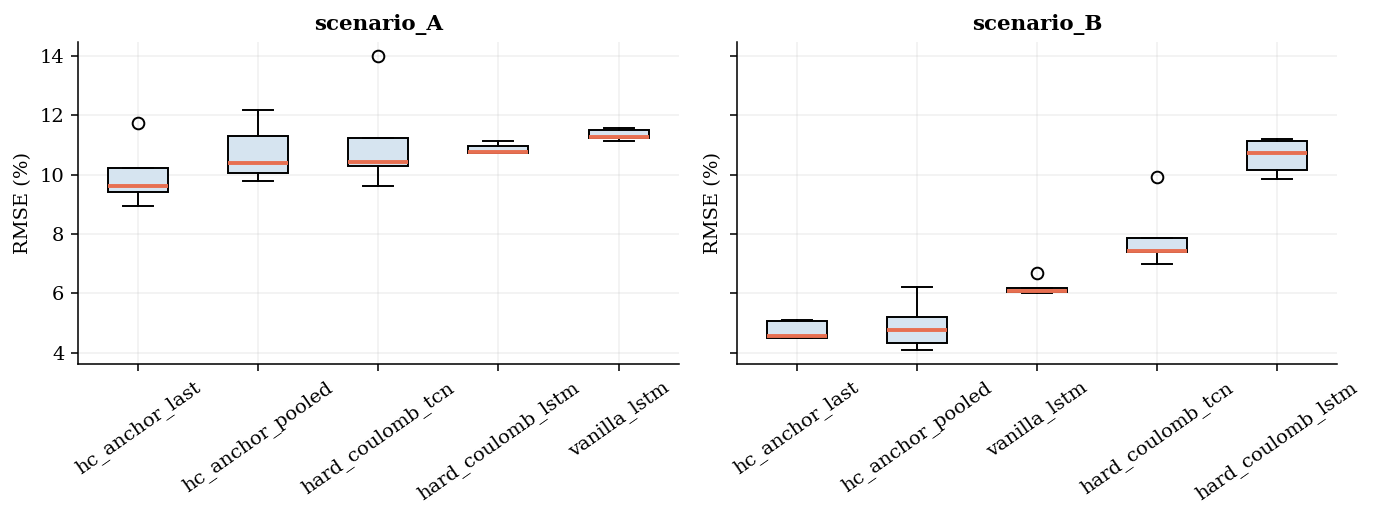

In [4]:
if not seed.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
    for ax, scenario in zip(axes, ["scenario_A","scenario_B"]):
        df = seed[seed["scenario"] == scenario]
        order = df.groupby("model")["rmse_pct"].median().sort_values().index.tolist()
        ax.boxplot([df[df["model"] == m]["rmse_pct"].values for m in order], labels=order, patch_artist=True, boxprops={"facecolor": "#D6E4F0"}, medianprops={"color": OUR_COLOR, "linewidth": 2})
        ax.set_title(scenario); ax.set_ylabel("RMSE (%)"); ax.tick_params(axis="x", rotation=35)
    plt.tight_layout(); plt.show()


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19372\314735105.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df["model"] == m]["maxe_pct"].values for m in order], labels=order, patch_artist=True, boxprops={"facecolor": "#F5DEB3"}, medianprops={"color": OUR_COLOR, "linewidth": 2})
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19372\314735105.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df["model"] == m]["maxe_pct"].values for m in order], labels=order, patch_artist=True, boxprops={"facecolor": "#F5DEB3"}, medianprops={"color": OUR_COLOR, "linewidth": 2})


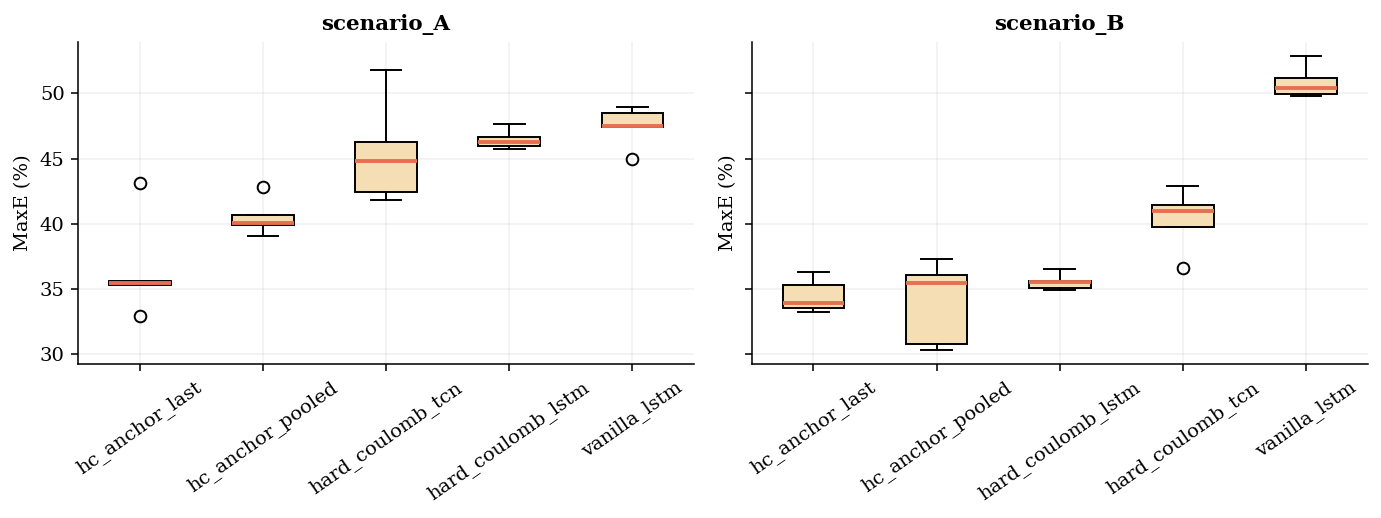

In [5]:
if not seed.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
    for ax, scenario in zip(axes, ["scenario_A","scenario_B"]):
        df = seed[seed["scenario"] == scenario]
        order = df.groupby("model")["maxe_pct"].median().sort_values().index.tolist()
        ax.boxplot([df[df["model"] == m]["maxe_pct"].values for m in order], labels=order, patch_artist=True, boxprops={"facecolor": "#F5DEB3"}, medianprops={"color": OUR_COLOR, "linewidth": 2})
        ax.set_title(scenario); ax.set_ylabel("MaxE (%)"); ax.tick_params(axis="x", rotation=35)
    plt.tight_layout(); plt.show()


In [6]:
if not seed.empty:
    b = seed[seed["scenario"] == "scenario_B"].pivot(index="seed", columns="model", values="rmse_pct")
    if {"hard_coulomb_lstm","vanilla_lstm"}.issubset(b.columns):
        b["original_hc_worse_than_vanilla"] = b["hard_coulomb_lstm"] > b["vanilla_lstm"]
        display(b[["hard_coulomb_lstm","vanilla_lstm","original_hc_worse_than_vanilla"]].round(4))
        display(Markdown(f"**Original HC Scenario-B failure count:** {int(b['original_hc_worse_than_vanilla'].sum())}/{len(b)} seeds."))
    display(Markdown("### Ranking stability JSON"))
    display(ranking)


model,hard_coulomb_lstm,vanilla_lstm,original_hc_worse_than_vanilla
seed,,,
1,9.8583,6.1674,True
2,11.2128,6.0234,True
3,10.1728,6.0578,True
4,10.7488,6.0735,True
5,11.1526,6.6765,True


**Original HC Scenario-B failure count:** 5/5 seeds.

### Ranking stability JSON

{'scenario_A': {'winner_by_seed': {'1': 'hc_anchor_last',
   '2': 'hc_anchor_last',
   '3': 'hc_anchor_last',
   '4': 'hc_anchor_last',
   '5': 'hard_coulomb_lstm'},
  'winner_stable': False},
 'scenario_B': {'winner_by_seed': {'1': 'hc_anchor_pooled',
   '2': 'hc_anchor_pooled',
   '3': 'hc_anchor_last',
   '4': 'hc_anchor_last',
   '5': 'hc_anchor_last'},
  'winner_stable': False}}

## Interpretation

The selected family is not a one-seed accident. `anchor_last` is the stable candidate across the corrected v5 ledger, while original first-anchor Hard-Coulomb LSTM has a systematic Scenario-B weakness.

## Reviewer-risk note

Ranking is stable enough for manuscript claims, but eta calibration remains single-checkpoint evidence unless rerun across seeds.

## Final conclusion

`anchor_last` is the stable candidate; original HC failure is systematic.


In [7]:
show_missing()


### Missing artifacts recorded by this notebook: none

## Publication asset export (PUBLICATION_ASSET_EXPORT_V1)

This cell exports manuscript-ready figures/tables from existing v5 CSV/JSON artifacts only. It does not run training or alter experiment results.


In [ ]:
# PUBLICATION_ASSET_EXPORT_V1
from pathlib import Path
import sys
EXPORT_DIR = Path('notebooks/ablation_studies_v5_final').resolve()
if str(EXPORT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPORT_DIR))
from publication_asset_exports import export_for_notebook
validation = export_for_notebook('14')
print('publication assets refreshed:', validation['png_present'], 'figures and', validation['csv_present'], 'tables')
